In [1]:
import os
import json
import math
import random
from pathlib import Path
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.data import random_split
from PIL import Image

import time
from torch.amp import autocast, GradScaler

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA H100 80GB HBM3 MIG 1g.10gb


In [2]:
DATA_ROOT = Path("~/data/det_compass_complete").expanduser()
IMG_DIR = DATA_ROOT / "images"

ANNOT_PATH = DATA_ROOT / "annotations.json"
MATERIAL_PATH = DATA_ROOT / "material_classification.json"
COLOR_PATH = DATA_ROOT / "colour_per_cat.json"

SAVE_DIR = Path("./RGBToXrayModel")
SAVE_DIR.mkdir(exist_ok=True)

print("Images:", IMG_DIR)
print("Save:", SAVE_DIR)

Images: /home/haree/scratch/haree/data/det_compass_complete/images
Save: RGBToXrayModel


In [3]:
with open(ANNOT_PATH) as f:
    annotations = json.load(f)

with open(MATERIAL_PATH) as f:
    material_map = json.load(f)

with open(COLOR_PATH) as f:
    color_map = json.load(f)

print("Annotations:", len(annotations))
print("Materials:", len(material_map))
print("Color classes:", len(color_map))

Annotations: 1573
Materials: 11
Color classes: 331


In [4]:
# Collect valid categories
all_categories = sorted({
    ann["objects"]["categories"][0]
    for ann in annotations
    if len(ann["objects"]["categories"]) > 0
})

# Add unknown
if "unknown" not in all_categories:
    all_categories.append("unknown")

cat_to_idx = {c: i for i, c in enumerate(all_categories)}

# Materials
all_materials = sorted(material_map.keys())
mat_to_idx = {m: i for i, m in enumerate(all_materials)}

print("Num categories:", len(cat_to_idx))
print("Num materials:", len(mat_to_idx))
print("Unknown idx:", cat_to_idx["unknown"])

Num categories: 313
Num materials: 11
Unknown idx: 312


In [5]:
def get_material(category):
    if category == "unknown":
        return "mixed_other"

    for m, items in material_map.items():
        if category in items:
            return m

    return "mixed_other"

In [6]:
def resize_pad(img, size=512):
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w * scale), int(h * scale)

    img = img.resize((nw, nh), Image.BILINEAR)
    canvas = Image.new("RGB", (size, size))
    canvas.paste(img, ((size - nw) // 2, (size - nh) // 2))

    return canvas

to_tensor = transforms.ToTensor()

In [7]:
CACHE_DIR = DATA_ROOT / "cache_512"
CACHE_DIR.mkdir(exist_ok=True)

def build_cache():
    for a in tqdm(annotations, desc="Caching"):
        stem = Path(a["rgb_file"]).stem
        out_file = CACHE_DIR / f"{stem}.pt"

        if out_file.exists():
            continue

        def load(fname):
            img = Image.open(IMG_DIR / fname).convert("RGB")
            img = resize_pad(img)
            return to_tensor(img)

        cats = a["objects"]["categories"]
        cat = cats[0] if len(cats) > 0 else "unknown"
        mat = get_material(cat)

        data = {
            "rgb": load(a["rgb_file"]),
            "xray_col": load(a["xray_files"][0]),
            "xray_gray": load(a["xray_files"][1]),
            "xray_hi": load(a["xray_files"][2]),
            "xray_lo": load(a["xray_files"][3]),
            "xray_den": load(a["xray_files"][4]),
            "cat": cat_to_idx[cat],
            "mat": mat_to_idx[mat],
            "color_prior": torch.tensor(
                color_map.get(cat, [128,128,128])
            ) / 255.0
        }

        torch.save(data, out_file)

build_cache()

print("Cache built at:", CACHE_DIR)
print("Cached files:", len(list(CACHE_DIR.glob("*.pt"))))

Caching: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1573/1573 [15:45<00:00,  1.66it/s]

Cache built at: /home/haree/scratch/haree/data/det_compass_complete/cache_512
Cached files: 1573


In [17]:
class CachedRGBXrayDataset(Dataset):
    def __init__(self, cache_dir):
        self.files = sorted(Path(cache_dir).glob("*.pt"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], weights_only=True)
        return {
            "rgb": data["rgb"],
            "xray_col": data["xray_col"],
            "xray_gray": data["xray_gray"],
            "xray_hi": data["xray_hi"],
            "xray_lo": data["xray_lo"],
            "xray_den": data["xray_den"],
            "cat": torch.tensor(data["cat"]),
            "mat": torch.tensor(data["mat"]),
            "color_prior": data["color_prior"].float()
        }

In [18]:
class RGBXrayDataset(Dataset):
    def __init__(self, annotations, img_dir):
        self.ann = annotations
        self.img_dir = img_dir

    def __len__(self):
        return len(self.ann)

    def load_img(self, fname):
        path = self.img_dir / fname
        img = Image.open(path).convert("RGB")
        img = resize_pad(img)
        return to_tensor(img)

    def __getitem__(self, idx):
        a = self.ann[idx]

        cats = a["objects"]["categories"]
        cat = cats[0] if len(cats) > 0 else "unknown"
        mat = get_material(cat)

        rgb = self.load_img(a["rgb_file"])
        xray_col = self.load_img(a["xray_files"][0])
        xray_gray = self.load_img(a["xray_files"][1])
        xray_hi = self.load_img(a["xray_files"][2])
        xray_lo = self.load_img(a["xray_files"][3])
        xray_den = self.load_img(a["xray_files"][4])

        color_prior = torch.tensor(
            color_map.get(cat, [128, 128, 128])
        ) / 255.0

        return {
            "rgb": rgb,
            "xray_col": xray_col,
            "xray_gray": xray_gray,
            "xray_hi": xray_hi,
            "xray_lo": xray_lo,
            "xray_den": xray_den,
            "cat": torch.tensor(cat_to_idx[cat]),
            "mat": torch.tensor(mat_to_idx[mat]),
            "color_prior": color_prior.float()
        }

In [19]:
dataset = CachedRGBXrayDataset(CACHE_DIR)

val_ratio = 0.1
n_total = len(dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train:", len(train_ds), "Val:", len(val_ds))

Train: 1416 Val: 157


In [20]:
class ConvBlock(nn.Module):
    def __init__(self, c1, c2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c1, c2, 3, 1, 1),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            nn.Conv2d(c2, c2, 3, 1, 1),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    def __init__(self, c1, c2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(c1, c2)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, c1, c2):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = ConvBlock(c1, c2)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], 1)
        return self.conv(x)

In [21]:
class MultiTaskUNet(nn.Module):
    def __init__(self, n_cat, n_mat):
        super().__init__()

        self.cat_emb = nn.Embedding(n_cat, 16)
        self.mat_emb = nn.Embedding(n_mat, 16)

        self.inc = ConvBlock(3 + 32, 64)
        self.d1 = Down(64, 128)
        self.d2 = Down(128, 256)
        self.d3 = Down(256, 512)

        self.u1 = Up(512 + 256, 256)
        self.u2 = Up(256 + 128, 128)
        self.u3 = Up(128 + 64, 64)

        self.out_col = nn.Conv2d(64, 3, 1)
        self.out_gray = nn.Conv2d(64, 3, 1)
        self.out_hi = nn.Conv2d(64, 3, 1)
        self.out_lo = nn.Conv2d(64, 3, 1)
        self.out_den = nn.Conv2d(64, 3, 1)

    def forward(self, rgb, cat, mat):
        B, C, H, W = rgb.shape

        ce = self.cat_emb(cat).view(B, 16, 1, 1).expand(-1, -1, H, W)
        me = self.mat_emb(mat).view(B, 16, 1, 1).expand(-1, -1, H, W)

        x = torch.cat([rgb, ce, me], 1)

        x1 = self.inc(x)
        x2 = self.d1(x1)
        x3 = self.d2(x2)
        x4 = self.d3(x3)

        x = self.u1(x4, x3)
        x = self.u2(x, x2)
        x = self.u3(x, x1)

        return {
            "col": torch.sigmoid(self.out_col(x)),
            "gray": torch.sigmoid(self.out_gray(x)),
            "hi": torch.sigmoid(self.out_hi(x)),
            "lo": torch.sigmoid(self.out_lo(x)),
            "den": torch.sigmoid(self.out_den(x)),
        }

In [22]:
def loss_fn(pred, batch):
    l1 = F.l1_loss(pred["col"], batch["xray_col"])
    l2 = F.l1_loss(pred["gray"], batch["xray_gray"])
    l3 = F.l1_loss(pred["hi"], batch["xray_hi"])
    l4 = F.l1_loss(pred["lo"], batch["xray_lo"])
    l5 = F.l1_loss(pred["den"], batch["xray_den"])

    cp = batch["color_prior"].view(-1, 3, 1, 1)
    col_mean = pred["col"].mean([2, 3], keepdim=True)
    l_color = F.l1_loss(col_mean, cp)

    return l1 + 0.5 * (l2 + l3 + l4 + l5) + 0.2 * l_color

In [23]:
if not torch.cuda.is_available():
    raise RuntimeError("❌ GPU required but not available")

device = torch.device("cuda")

model = MultiTaskUNet(len(cat_to_idx), len(mat_to_idx)).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)

print("GPU:", torch.cuda.get_device_name(0))
print("Params:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

GPU: NVIDIA H100 80GB HBM3 MIG 1g.10gb
Params: 7.813071 M


In [24]:
# ---- GPU status before training ----
gpu_available = torch.cuda.is_available()
model_on_gpu = next(model.parameters()).device.type == "cuda"

print("GPU available:", gpu_available)
print("Model on GPU:", model_on_gpu)

if not gpu_available:
    raise RuntimeError("❌ CUDA GPU not available — aborting")

if not model_on_gpu:
    raise RuntimeError("❌ Model not on GPU — aborting")

print("✅ Training will run on:", torch.cuda.get_device_name(0))

GPU available: True
Model on GPU: True
✅ Training will run on: NVIDIA H100 80GB HBM3 MIG 1g.10gb


In [25]:
EPOCHS = 100
SAVE_EVERY = 10

scaler = GradScaler("cuda")
best_val = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    num_batches = len(train_loader)
    progress_marks = {int(num_batches * p / 5) for p in range(1, 5)}

    for i, batch in enumerate(train_loader, 1):
        for k in batch:
            if isinstance(batch[k], torch.Tensor):
                batch[k] = batch[k].to(device, non_blocking=True)

        if epoch == 1 and i == 1:
            print("Batch device:", batch["rgb"].device)

        with autocast("cuda"):
            pred = model(batch["rgb"], batch["cat"], batch["mat"])
            loss = loss_fn(pred, batch)

        opt.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        running += loss.item()

        if i in progress_marks:
            pct = 100 * i / num_batches
            print(f"  epoch {epoch:03d} {pct:3.0f}% loss: {loss.item():.4f}")

    train_loss = running / num_batches

    # ---- VALIDATION ----
    model.eval()
    val_running = 0.0

    with torch.no_grad():
        for batch in val_loader:
            for k in batch:
                if isinstance(batch[k], torch.Tensor):
                    batch[k] = batch[k].to(device, non_blocking=True)

            with autocast("cuda"):
                pred = model(batch["rgb"], batch["cat"], batch["mat"])
                vloss = loss_fn(pred, batch)

            val_running += vloss.item()

    val_loss = val_running / len(val_loader)

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"{100*epoch/EPOCHS:4.1f}% | "
        f"TrainLoss {train_loss:.4f} | "
        f"ValLoss {val_loss:.4f}"
    )

    # save periodic
    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), SAVE_DIR / f"epoch_{epoch:03d}.pt")

    # save best
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), SAVE_DIR / "best.pt")

torch.save(model.state_dict(), SAVE_DIR / "final.pt")

Batch device: cuda:0
  epoch 001  20% loss: 1.0267
  epoch 001  40% loss: 0.8853
  epoch 001  60% loss: 0.7312
  epoch 001  80% loss: 0.6876
Epoch 001/100 |  1.0% | TrainLoss 0.8405 | ValLoss 0.7063
  epoch 002  20% loss: 0.5062
  epoch 002  40% loss: 0.5246
  epoch 002  60% loss: 0.4178
  epoch 002  80% loss: 0.6181
Epoch 002/100 |  2.0% | TrainLoss 0.4504 | ValLoss 0.4120
  epoch 003  20% loss: 0.5486
  epoch 003  40% loss: 0.3079
  epoch 003  60% loss: 0.2302
  epoch 003  80% loss: 0.2454
Epoch 003/100 |  3.0% | TrainLoss 0.2970 | ValLoss 0.3062
  epoch 004  20% loss: 0.5161
  epoch 004  40% loss: 0.1800
  epoch 004  60% loss: 0.2033
  epoch 004  80% loss: 0.5546
Epoch 004/100 |  4.0% | TrainLoss 0.2328 | ValLoss 0.2234
  epoch 005  20% loss: 0.1396
  epoch 005  40% loss: 0.1509
  epoch 005  60% loss: 0.2491
  epoch 005  80% loss: 0.1496
Epoch 005/100 |  5.0% | TrainLoss 0.2005 | ValLoss 0.1952
  epoch 006  20% loss: 0.1354
  epoch 006  40% loss: 0.1242
  epoch 006  60% loss: 0.1511

In [26]:
to_pil = transforms.ToPILImage()

def rgb_to_xray(img_path, category="unknown"):
    if not torch.cuda.is_available():
        raise RuntimeError("GPU required for inference")

    model.eval()

    img = Image.open(img_path).convert("RGB")
    img = resize_pad(img)
    t = to_tensor(img).unsqueeze(0).to(device)

    cat_name = category if category in cat_to_idx else "unknown"
    mat_name = get_material(cat_name)

    cat = torch.tensor([cat_to_idx[cat_name]], device=device)
    mat = torch.tensor([mat_to_idx[mat_name]], device=device)

    with torch.no_grad():
        out = model(t, cat, mat)["col"][0].cpu()

    return to_pil(out)

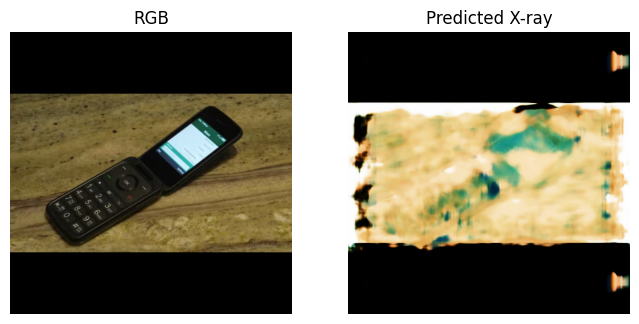

In [35]:
import matplotlib.pyplot as plt

test_img = "d2.jpg"   # example

pred = rgb_to_xray(test_img, category="unknown")

# display
rgb = Image.open(test_img).convert("RGB")
rgb = resize_pad(rgb)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("RGB")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted X-ray")
plt.imshow(pred)
plt.axis("off")

plt.show()